# Prepare the environment for HDR reconstruction

In [1]:
import cv2 as cv
import numpy as np
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from config import OVEREXPOSED_IMAGES_DIR, UNDEREXPOSED_IMAGES_DIR, LDR_DIR, HDR_DIR, HDR_RECONSTRUCTION_IMAGES_DIR, HDR_RECONSTRUCTION_PREVIEW_DIR, BRACKETED_IMAGES_DIR, HDR_TARGET_PREVIEW_DIR, HDR_RECONSTRUCTION_DIR
from utils import tone_map_reinhard, measure_ev_range, read_hdr, get_exif

In [2]:
HDR_RECONSTRUCTION_IMAGES_DIR.mkdir(exist_ok=True, parents=True)
HDR_RECONSTRUCTION_PREVIEW_DIR.mkdir(exist_ok=True, parents=True)
HDR_TARGET_PREVIEW_DIR.mkdir(exist_ok=True, parents=True)

# Debevec algorithm

In [3]:
def debevec_algorithm(images_list: list, exposure_times: list) -> np.ndarray:
    exposure_times_array = np.array(exposure_times, dtype=np.float32)

    calibrate = cv.createCalibrateDebevec()
    response_crv = calibrate.process(images_list, times=exposure_times_array)

    merge_debevec = cv.createMergeDebevec()
    hdr_bgr = merge_debevec.process(images_list, times=exposure_times_array, response=response_crv)

    return hdr_bgr

# Exposure time extraction and base exposure finding

In [4]:
def get_exposure_time(image_path: str) -> float:
    exif = get_exif(image_path)
    value = exif.get("ExposureTime")

    if value is None:
        raise ValueError(f"No ExposureTime tag in {image_path}")

    return float(value)

In [5]:
def find_base_exposure(bracketed_dir: Path, ldr_tif_path: Path) -> float:
    THUMB = (256, 256)

    ldr_img  = cv.imread(str(ldr_tif_path), cv.IMREAD_COLOR)
    ldr_img  = cv.resize(ldr_img, THUMB).astype(np.float32)
    ldr_mean = cv.cvtColor(ldr_img, cv.COLOR_BGR2GRAY).mean()

    all_jpegs = list(bracketed_dir.glob("*.JPG")) + \
                list(bracketed_dir.glob("*.jpg")) + \
                list(bracketed_dir.glob("*.jpeg")) + \
                list(bracketed_dir.glob("*.JPEG"))

    best_time, best_diff = None, float("inf")

    for f in sorted(all_jpegs):
        try:
            t    = get_exposure_time(str(f))
            img  = cv.imread(str(f), cv.IMREAD_COLOR)
            img  = cv.resize(img, THUMB).astype(np.float32)
            mean = cv.cvtColor(img, cv.COLOR_BGR2GRAY).mean()
            diff = abs(mean - ldr_mean)
            if diff < best_diff:
                best_diff, best_time = diff, t
        except Exception as e:
            print(f"  SKIPPED {f.name}: {e}")
            continue

    if best_time is None:
        raise FileNotFoundError(f"No readable JPEGs with EXIF in {bracketed_dir}")

    return best_time

In [6]:
base_times = {}

for overexposed_image_path in OVEREXPOSED_IMAGES_DIR.glob("*.png"):
    scene = overexposed_image_path.stem[:3].upper()
    ldr_image_path = LDR_DIR / f"{overexposed_image_path.stem}.tif"
    bracketed_scene_dir = BRACKETED_IMAGES_DIR / scene

    try:
        t = find_base_exposure(bracketed_scene_dir, ldr_image_path)
        base_times[scene] = t
    except Exception:
        pass

fallback_exposure = float(np.median(list(base_times.values()))) if base_times else 1/50
print(f"Fallback exposure time: {fallback_exposure:.5f}s")

  SKIPPED DSC03972.JPG_crop.jpg: Missing metadata for image /home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project2-ldr-to-hdr/data/images/Bracketed_images/C42/DSC03972.JPG_crop.jpg
  SKIPPED DSC03973.JPG_crop.jpg: Missing metadata for image /home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project2-ldr-to-hdr/data/images/Bracketed_images/C42/DSC03973.JPG_crop.jpg
  SKIPPED DSC03974.JPG_crop.jpg: Missing metadata for image /home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project2-ldr-to-hdr/data/images/Bracketed_images/C42/DSC03974.JPG_crop.jpg
  SKIPPED DSC03975.JPG_crop.jpg: Missing metadata for image /home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project2-ldr-to-hdr/data/images/Bracketed_images/C42/DSC03975.JPG_crop.jpg
  SKIPPED DSC03976.JPG_crop.jpg: Missing metadata for image /home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project2-ldr-to-hdr/data/images/Bracketed_images/C42/DSC03976.JPG_crop.jpg
  SKIPPED DSC03977.J

# Image utils

In [7]:
def load_image_as_uint8_bgr(path: str) -> np.ndarray:
    img = cv.imread(path, cv.IMREAD_COLOR)

    if img is None:
        raise FileNotFoundError(f"Cannot read image: {path}")

    if img.dtype != np.uint8:
        img = cv.normalize(img, None, 0, 255, cv.NORM_MINMAX)
        img = img.astype(np.uint8)

    return img

In [8]:
def save_hdr_image(hdr_bgr: np.ndarray, output_dir: Path, scene: str) -> Path:
    hdr_save_path = output_dir / f"{scene}_reconstructed.hdr"
    cv.imwrite(hdr_save_path, hdr_bgr)

    return hdr_save_path

In [9]:
def create_preview_hdr_image(hdr_bgr: np.ndarray, output_dir: Path, scene: str) -> np.ndarray:
    tone_mapped_image = tone_map_reinhard(hdr_bgr)
    preview = np.clip(tone_mapped_image * 255, 0, 255).astype(np.uint8)

    preview_path = output_dir / f"{scene}_tonemapped.png"

    cv.imwrite(preview_path, preview)

# Process images and reconstruct HDR

In [10]:
results = []

for overexposed_image_path in OVEREXPOSED_IMAGES_DIR.glob("*.png"):
    scene = overexposed_image_path.stem[:3].upper()
    print(f"Processing scene: {scene}")

    underexposed_image_path = UNDEREXPOSED_IMAGES_DIR / overexposed_image_path.name
    ldr_image_path = LDR_DIR / f"{overexposed_image_path.stem}.tif"
    target_hdr_image_path = HDR_DIR / f"{overexposed_image_path.stem.replace("LDR", "HDR")}.hdr"

    if not underexposed_image_path.exists():
        print(f"Warning: Underexposed image not found for {overexposed_image_path.name}")
        continue

    if not ldr_image_path.exists():
        print(f"Warning: LDR image not found for {overexposed_image_path.name}")
        continue

    if not target_hdr_image_path.exists():
        print(f"Warning: Target HDR image not found for {overexposed_image_path.name}")
        continue

    bracketed_scene_dir = BRACKETED_IMAGES_DIR / scene

    t_base  = base_times.get(scene, fallback_exposure)
    t_under = t_base * (2 ** -2.7)
    t_over  = t_base * (2 **  2.7)

    print(f"t_base={t_base:.5f}s | t_under={t_under:.5f}s | t_over={t_over:.5f}s")

    overexposed_image = load_image_as_uint8_bgr(overexposed_image_path)
    underexposed_image = load_image_as_uint8_bgr(underexposed_image_path)
    ldr_image = load_image_as_uint8_bgr(ldr_image_path)

    images_list = [underexposed_image, ldr_image, overexposed_image]
    exposure_times = [t_under, t_base, t_over]

    hdr_bgr = debevec_algorithm(images_list, exposure_times)

    hdr_path = save_hdr_image(hdr_bgr, HDR_RECONSTRUCTION_IMAGES_DIR, scene)
    create_preview_hdr_image(hdr_bgr, HDR_RECONSTRUCTION_PREVIEW_DIR, scene)

    hdr_image = read_hdr(str(hdr_path))
    dynamic_range = measure_ev_range(hdr_image)

    target_hdr = read_hdr(target_hdr_image_path)
    create_preview_hdr_image(target_hdr, HDR_TARGET_PREVIEW_DIR, scene)
    dynamic_range_target = measure_ev_range(target_hdr)

    results.append({
        "Scene":                   scene,
        "Dynamic Range Original":  dynamic_range_target,
        "Dynamic Range New":       dynamic_range,
    })

    print(f"Dynamic range of reconstructed HDR for {scene}: {dynamic_range:.2f} EV")
    print(f"Dynamic range of target HDR for {scene}: {dynamic_range_target:.2f} EV")

Processing scene: C40
t_base=0.00313s | t_under=0.00048s | t_over=0.02031s


[ WARN:0@4.007] global matrix_expressions.cpp:1333 assign OpenCV/MatExpr: processing of multi-channel arrays might be changed in the future: https://github.com/opencv/opencv/issues/16739
/tmp/ipykernel_145973/2947638204.py:3: RuntimeWarning: invalid value encountered in cast
  preview = np.clip(tone_mapped_image * 255, 0, 255).astype(np.uint8)


Dynamic range of reconstructed HDR for C40: 6.22 EV
Dynamic range of target HDR for C40: 20.27 EV
Processing scene: C41
t_base=0.00625s | t_under=0.00096s | t_over=0.04061s
Dynamic range of reconstructed HDR for C41: 6.58 EV
Dynamic range of target HDR for C41: 18.00 EV
Processing scene: C42
t_base=0.00400s | t_under=0.00062s | t_over=0.02599s
Dynamic range of reconstructed HDR for C42: 6.94 EV
Dynamic range of target HDR for C42: 8.18 EV
Processing scene: C43
t_base=0.00400s | t_under=0.00062s | t_over=0.02599s
Dynamic range of reconstructed HDR for C43: 7.58 EV
Dynamic range of target HDR for C43: 24.30 EV
Processing scene: C44
t_base=0.00400s | t_under=0.00062s | t_over=0.02599s
Dynamic range of reconstructed HDR for C44: 5.78 EV
Dynamic range of target HDR for C44: 7.17 EV
Processing scene: C45
t_base=0.00400s | t_under=0.00062s | t_over=0.02599s
Dynamic range of reconstructed HDR for C45: 7.45 EV
Dynamic range of target HDR for C45: 8.39 EV
Processing scene: C46
t_base=0.00400s | 

# Display results

In [11]:
df_dynamic_range = pd.DataFrame(results).set_index("Scene").sort_index()
df_dynamic_range

,Dynamic Range Original,Dynamic Range New
Scene,,
C40,20.267975,6.221790
C41,17.996151,6.580147
C42,8.178262,6.935391
C43,24.301859,7.583825
C44,7.169200,5.776097
C45,8.394124,7.449384
C46,14.071410,6.992755


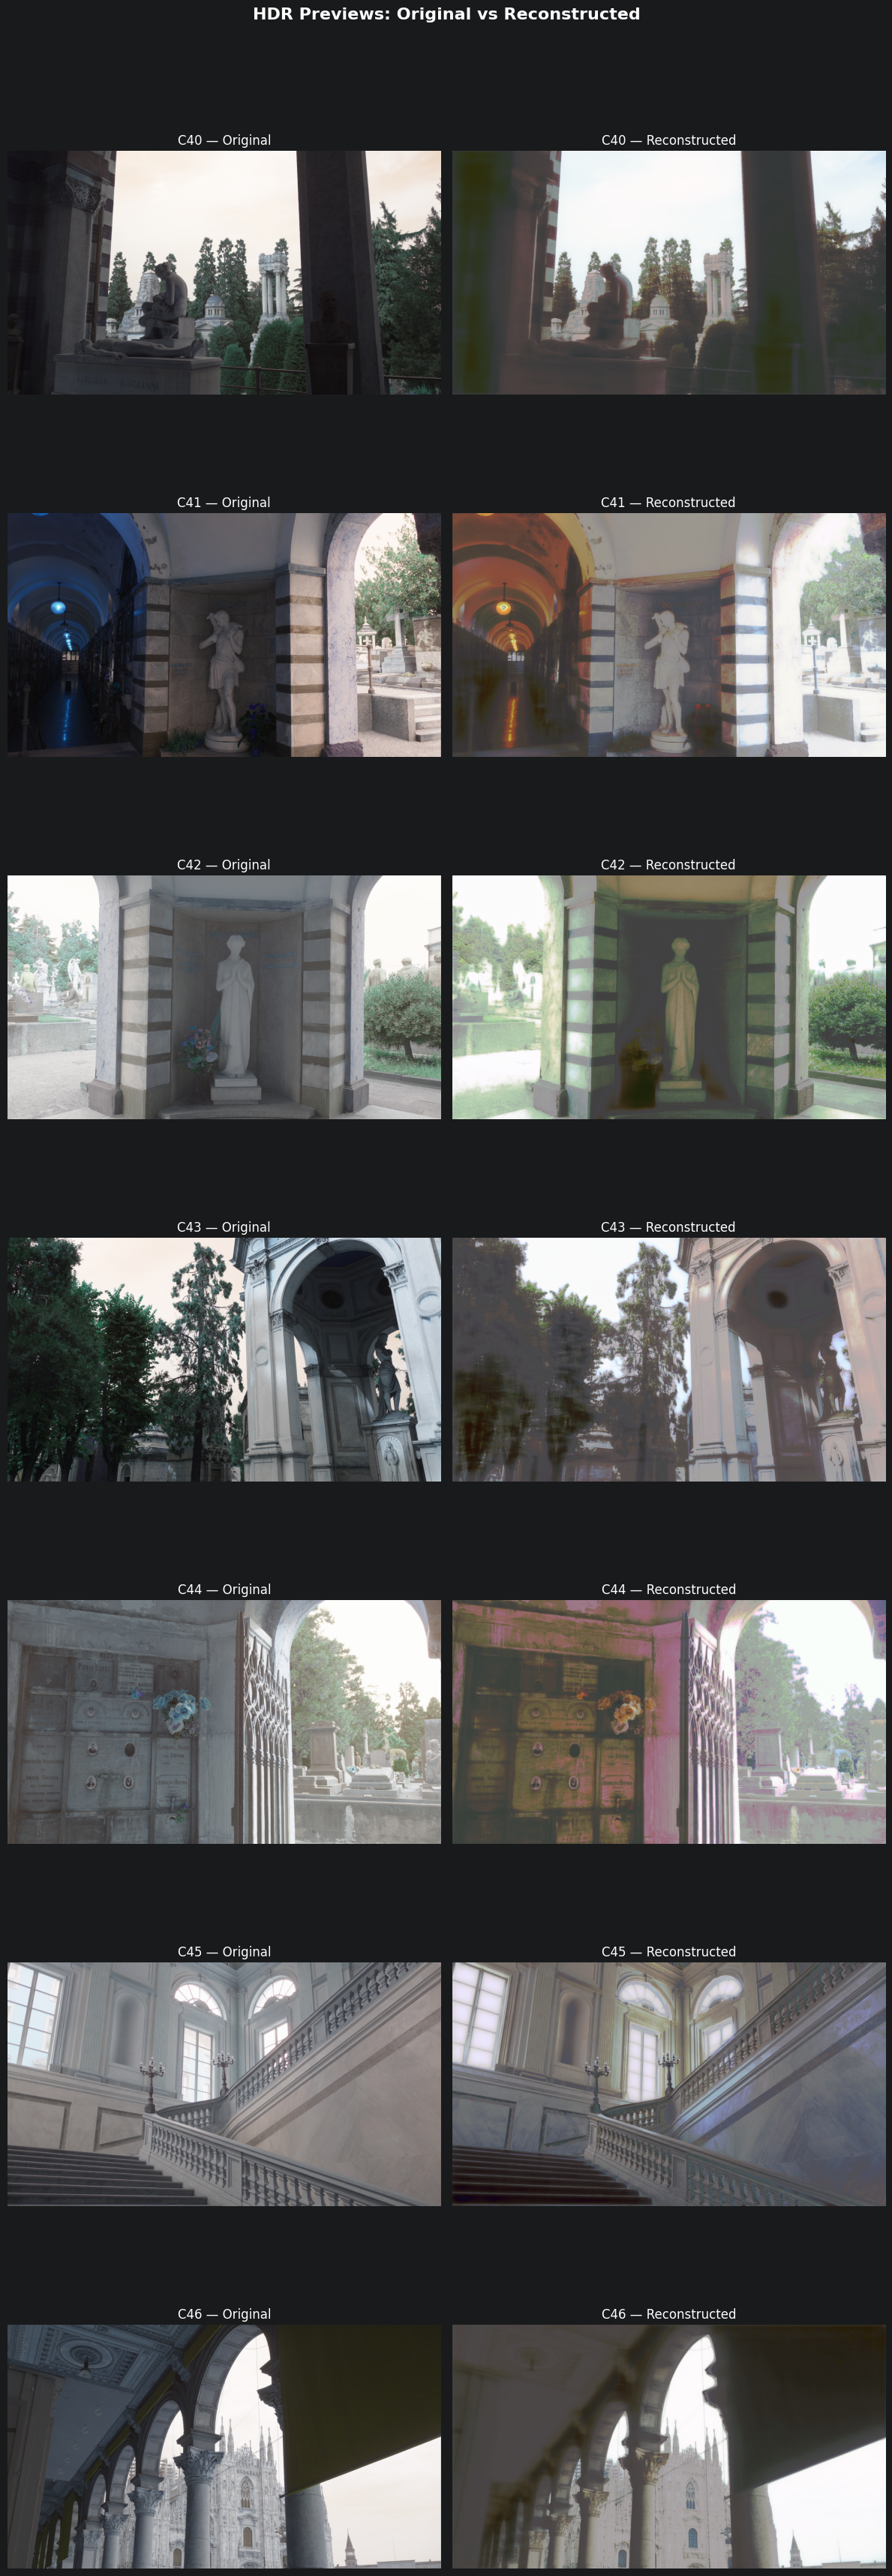

In [12]:
reconstructed_paths = sorted(HDR_RECONSTRUCTION_PREVIEW_DIR.glob("*.png"))

fig, axes = plt.subplots(len(reconstructed_paths), 2, figsize=(12, 5 * len(reconstructed_paths)))
fig.suptitle("HDR Previews: Original vs Reconstructed", fontsize=16, fontweight="bold", y=1.01)

for row, recon_path in enumerate(reconstructed_paths):
    scene = recon_path.stem[:3].upper()
    target_path = HDR_TARGET_PREVIEW_DIR / recon_path.name

    if not target_path.exists():
        print(f"Warning: target preview not found for {scene}")
        continue

    recon_img  = mpimg.imread(str(recon_path))
    target_img = mpimg.imread(str(target_path))

    axes[row, 0].imshow(target_img)
    axes[row, 0].set_title(f"{scene} — Original", fontsize=12)
    axes[row, 0].axis("off")
    axes[row, 1].imshow(recon_img)
    axes[row, 1].set_title(f"{scene} — Reconstructed", fontsize=12)
    axes[row, 1].axis("off")

plt.tight_layout()
plt.savefig(HDR_RECONSTRUCTION_DIR / "hdr_previews.png", dpi=300, bbox_inches="tight")
plt.show()